In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import SEED

import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
from src.config import DATA_PROC
from src.mlp import train_mlp

/opt/miniconda3/envs/pf_ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### PCA y Varianza explicada para MLP

Muestra cargada:
Matriz: (5000, 49152)  (0.25 GB)
Calculo PCA:
Componentes para 90% de varianza: 356


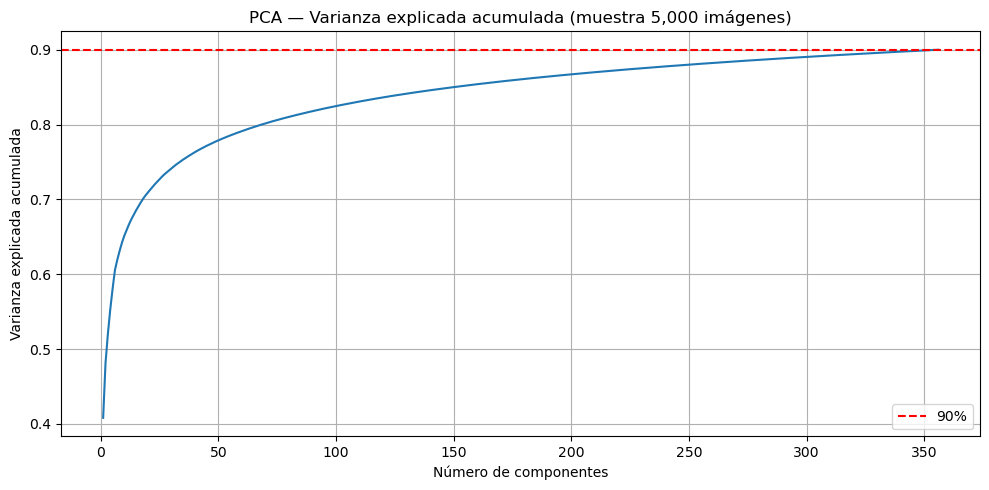

In [2]:
import random
random.seed(SEED)

# Muestra aleatoria de 5000 imágenes para el análisis de PCA
todos_los_paths = [
    p
    for label in ("real", "fake")
    for p in sorted((DATA_PROC / "train" / label).iterdir())
]
muestra = random.sample(todos_los_paths, 5000)

print("Muestra cargada:")
filas = []
for p in muestra:
    with Image.open(p) as img:
        filas.append(np.array(img, dtype=np.uint8).flatten())
X = np.stack(filas)
print(f"Matriz: {X.shape}  ({X.nbytes / 1e9:.2f} GB)")

# Uso 5000 muestras para q SVD exacto sea manejable
print("Calculo PCA:")
pca = PCA(n_components=0.90, svd_solver='full', whiten=True, random_state=SEED)
pca.fit(X)
n_comp = pca.n_components_
print(f"Componentes para 90% de varianza: {n_comp}")

# Gráfico de varianza explicada acumulada
varianza_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_comp + 1), varianza_acum)
plt.axhline(0.90, color="r", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA — Varianza explicada acumulada (muestra 5,000 imágenes)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [3]:
import joblib
from src.config import OUTPUTS

OUTPUTS.mkdir(exist_ok=True)
joblib.dump(pca, OUTPUTS / "pca_mlp.joblib")
print(f"PCA guardado en {OUTPUTS / 'pca_mlp.joblib'}")

PCA guardado en /Users/lautarocaminoa/Documents/UdeSA/Materias/ML/ProyectoFinal/PF_ML_Krinisky_Caminoa/outputs/pca_mlp.joblib


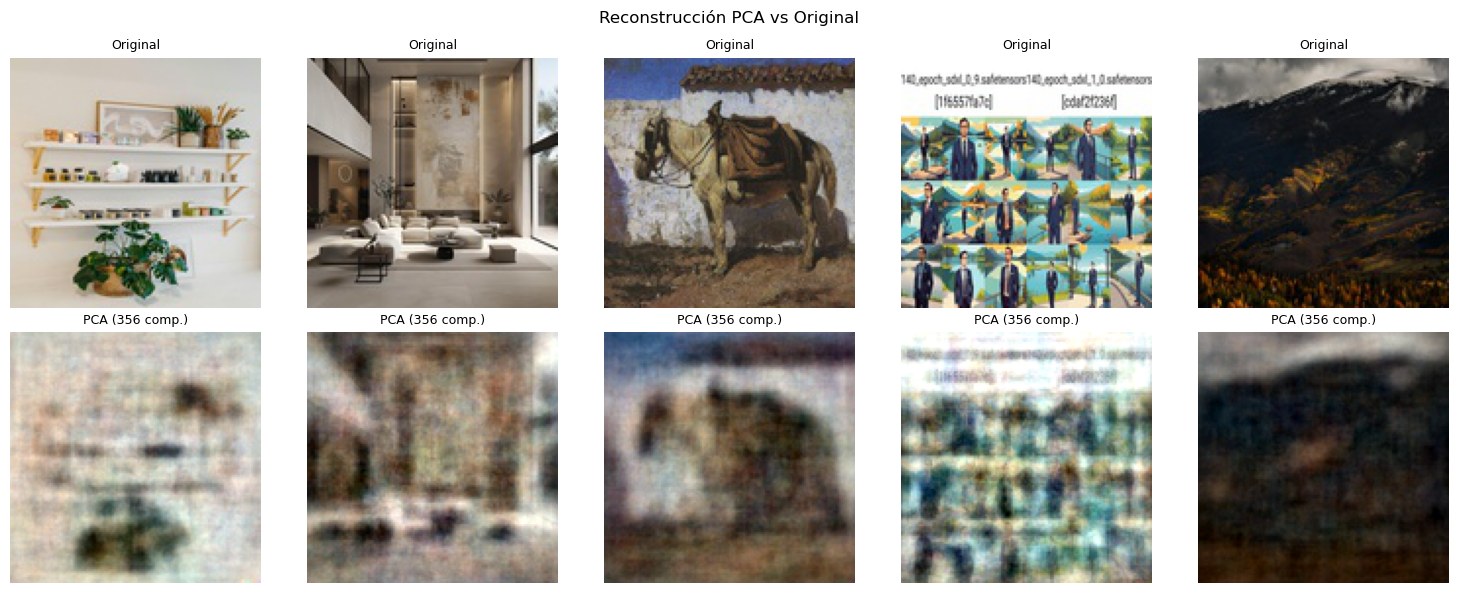

In [4]:
# Comparación visual: original vs reconstruida con PCA
n_mostrar = 5
indices = random.sample(range(len(filas)), n_mostrar)

fig, axes = plt.subplots(2, n_mostrar, figsize=(3 * n_mostrar, 6))

for col, idx in enumerate(indices):
    img_flat = filas[idx].reshape(1, -1)

    img_orig = filas[idx].reshape(128, 128, 3)
    img_rec  = pca.inverse_transform(pca.transform(img_flat)).reshape(128, 128, 3)
    img_rec  = np.clip(img_rec, 0, 255).astype(np.uint8)

    axes[0, col].imshow(img_orig)
    axes[0, col].set_title("Original", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(img_rec)
    axes[1, col].set_title(f"PCA ({n_comp} comp.)", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Reconstrucción PCA vs Original", fontsize=12)
plt.tight_layout()
plt.show()

Dispositivo: mps


Train: torch.Size([38395, 356]) | Val: torch.Size([9596, 356])
Epoch   1/50  train_loss=0.6300  val_loss=0.5904  val_acc=0.6843
Epoch   2/50  train_loss=0.5624  val_loss=0.5716  val_acc=0.6992
Epoch   3/50  train_loss=0.5180  val_loss=0.5650  val_acc=0.7065
Epoch   4/50  train_loss=0.4847  val_loss=0.5714  val_acc=0.7136
Epoch   5/50  train_loss=0.4513  val_loss=0.5820  val_acc=0.7154
Epoch   6/50  train_loss=0.4232  val_loss=0.5823  val_acc=0.7114
Epoch   7/50  train_loss=0.3967  val_loss=0.6101  val_acc=0.7169
Epoch   8/50  train_loss=0.3721  val_loss=0.6090  val_acc=0.7061
Epoch   9/50  train_loss=0.3465  val_loss=0.6249  val_acc=0.7039
Epoch  10/50  train_loss=0.3276  val_loss=0.6519  val_acc=0.7070
Epoch  11/50  train_loss=0.3148  val_loss=0.6508  val_acc=0.7064
Epoch  12/50  train_loss=0.2991  val_loss=0.6597  val_acc=0.7041
Epoch  13/50  train_loss=0.2851  val_loss=0.6862  val_acc=0.7036
Early stopping en epoch 13.

Mejor val_loss: 0.5650


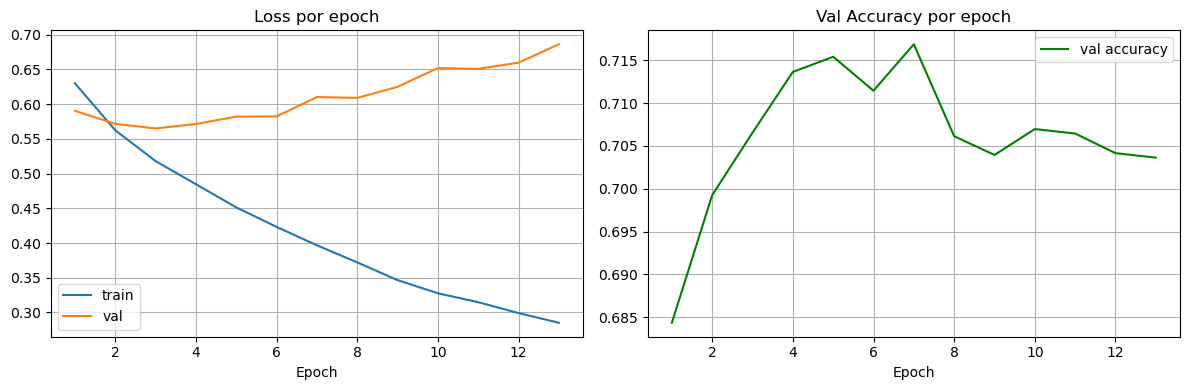

In [5]:
historia = train_mlp()